<a href="https://colab.research.google.com/github/Leeraaa/Machine-learning/blob/main/MachineLearningProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries and Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import seaborn as sns


from scipy.stats import chi2_contingency
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from tqdm.notebook import tqdm
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df= pd.read_csv(r'C:\HIT\death_prediction_synthetic.csv')

In [ ]:
df.shape

(12438, 45)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12438 entries, 0 to 12437
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  12438 non-null  int64  
 1   sex                  12438 non-null  int64  
 2   marital_status       12438 non-null  object 
 3   ses                  12438 non-null  int64  
 4   residence_cd         12438 non-null  int64  
 5   residence            12438 non-null  object 
 6   weigh                12438 non-null  float64
 7   heigh                12438 non-null  float64
 8   BMI                  12438 non-null  float64
 9   bp_sys               12438 non-null  int64  
 10  bp_dias              12438 non-null  int64  
 11  bp_cat               12438 non-null  object 
 12  smoking              12438 non-null  int64  
 13  smoking_status       12438 non-null  object 
 14  HbA1c                12438 non-null  float64
 15  glucose              12438 non-null 

In [ ]:
df.describe()

,age,sex,ses,residence_cd,weigh,heigh,BMI,bp_sys,bp_dias,smoking,...,framingham_cvd,antidiabetics,ERD,CVD,HTN,cancer,cardiovascular_meds,statines,immigrant,dead_5y
count,12438.000000,12438.000000,12438.000000,12438.000000,12438.000000,12438.000000,12438.000000,12438.000000,12438.000000,12438.000000,...,12438.000000,12438.000000,12438.000000,12438.000000,12438.000000,12438.0,12438.000000,12438.000000,12438.000000,12438.000000
mean,43.501126,1.468805,1.677279,1.062631,89.837746,167.943906,31.871922,124.803988,77.315163,1.636678,...,0.127533,0.857694,0.006593,0.092057,0.318058,0.0,0.602669,0.702203,0.174867,0.015839
std,4.802035,0.499046,0.763641,0.242307,19.296247,10.068620,6.459714,13.615760,8.915362,0.871735,...,0.092716,0.349378,0.080931,0.289117,0.465741,0.0,0.489365,0.457308,0.379869,0.124856
min,30.000000,1.000000,1.000000,1.000000,41.000000,91.500000,15.790000,75.000000,40.000000,1.000000,...,0.007310,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,41.000000,1.000000,1.000000,1.000000,76.000000,160.000000,27.400000,118.000000,70.000000,1.000000,...,0.061800,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
50%,45.000000,1.000000,1.000000,1.000000,88.000000,168.000000,31.050000,124.000000,79.000000,1.000000,...,0.102370,1.000000,0.000000,0.000000,0.000000,0.0,1.000000,1.000000,0.000000,0.000000
75%,48.000000,2.000000,2.000000,1.000000,100.000000,175.000000,35.350000,130.000000,80.000000,3.000000,...,0.163960,1.000000,0.000000,0.000000,1.000000,0.0,1.000000,1.000000,0.000000,0.000000
max,49.000000,2.000000,3.000000,2.000000,203.000000,202.000000,95.550000,200.000000,135.000000,3.000000,...,0.802220,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000


# Missing Values

In [ ]:
# Number of NaNs in each column
print(df.isna().sum())

age                       0
sex                       0
marital_status            0
ses                       0
residence_cd              0
residence                 0
weigh                     0
heigh                     0
BMI                       0
bp_sys                    0
bp_dias                   0
bp_cat                    0
smoking                   0
smoking_status            0
HbA1c                     0
glucose                   0
creatinin                 0
albumin                1463
alb24h                 8918
ACR                    1212
cholesterol_total         0
LDL                       0
HDL                       0
triglycerides             0
TSH                       0
gravity_u              2530
nitrites_u             2520
leuko_u                2507
proteinuria            2506
WBC                       0
RBC                       0
platelets                 0
MCV                       0
MPV                       0
Charlson                  0
framingham_cvd      

In [ ]:
# Nan percentages are calculated relative to the total number of rows
total_rows = len(df)
missing_percent = df.isna().sum() / total_rows * 100
print(missing_percent)

age                     0.000000
sex                     0.000000
marital_status          0.000000
ses                     0.000000
residence_cd            0.000000
residence               0.000000
weigh                   0.000000
heigh                   0.000000
BMI                     0.000000
bp_sys                  0.000000
bp_dias                 0.000000
bp_cat                  0.000000
smoking                 0.000000
smoking_status          0.000000
HbA1c                   0.000000
glucose                 0.000000
creatinin               0.000000
albumin                11.762341
alb24h                 71.699630
ACR                     9.744332
cholesterol_total       0.000000
LDL                     0.000000
HDL                     0.000000
triglycerides           0.000000
TSH                     0.000000
gravity_u              20.340891
nitrites_u             20.260492
leuko_u                20.155974
proteinuria            20.147934
WBC                     0.000000
RBC       

Number of NaNs in each column:
albumin        1463
alb24h         8918
ACR            1212
gravity_u      2530
nitrites_u     2520
leuko_u        2507
proteinuria    2506
dtype: int64

Statistics for columns with NaNs:

Analysis of column: albumin
count    10975.000000
mean         4.327445
std          0.329294
min          2.500000
25%          4.100000
50%          4.300000
75%          4.530000
max          5.700000
Name: albumin, dtype: float64


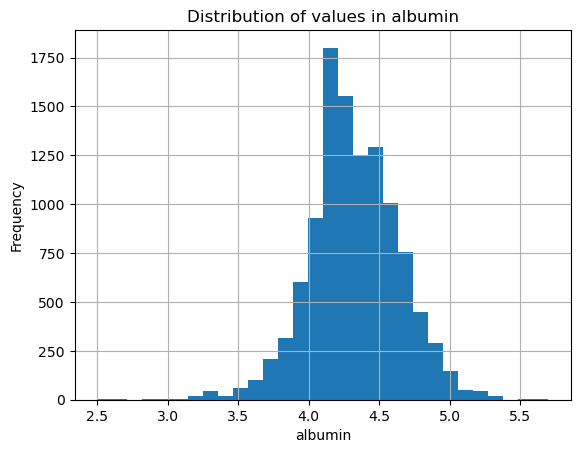


Analysis of column: alb24h
count      3520.000000
mean        219.855858
std        4084.373676
min           0.000000
25%          10.000000
50%          17.800000
75%          50.000000
max      170385.000000
Name: alb24h, dtype: float64


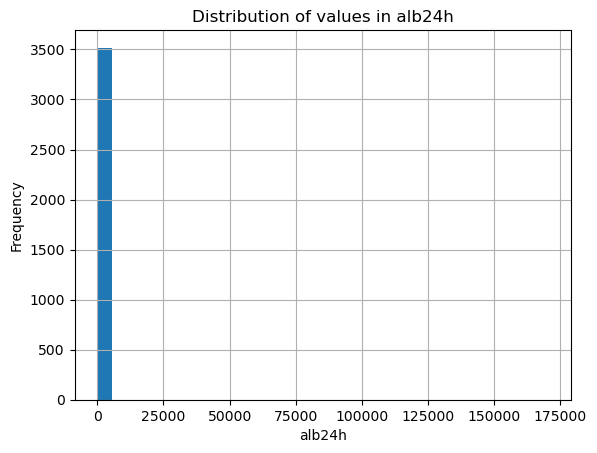


Analysis of column: ACR
count    11226.000000
mean        38.829212
std        117.962082
min          0.000000
25%          3.870000
50%          7.000000
75%         21.000000
max       1494.570000
Name: ACR, dtype: float64


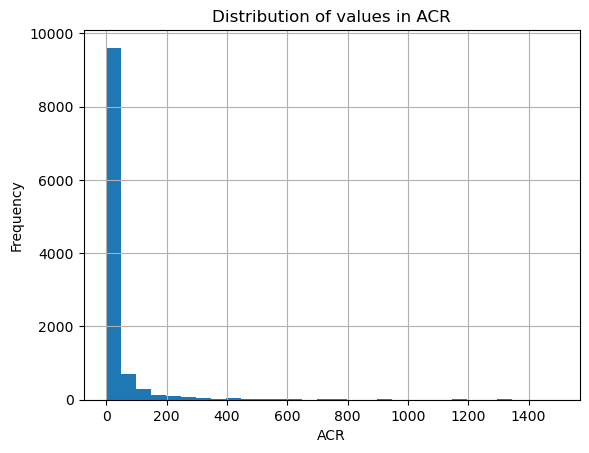


Analysis of column: gravity_u
count    9908.000000
mean        1.022250
std         0.008226
min         1.000000
25%         1.016000
50%         1.021000
75%         1.028000
max         1.050000
Name: gravity_u, dtype: float64


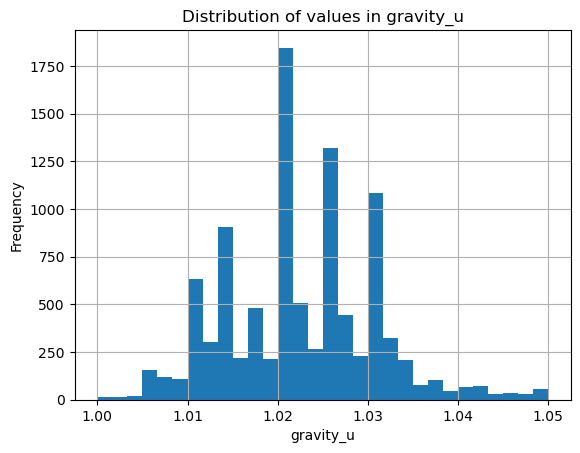


Analysis of column: nitrites_u
count    9918.000000
mean        0.037709
std         0.202310
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: nitrites_u, dtype: float64


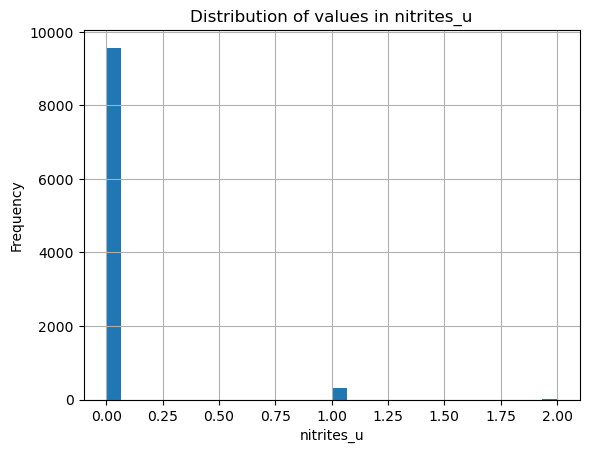


Analysis of column: leuko_u
count    9931.000000
mean       40.851576
std       120.788718
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       500.000000
Name: leuko_u, dtype: float64


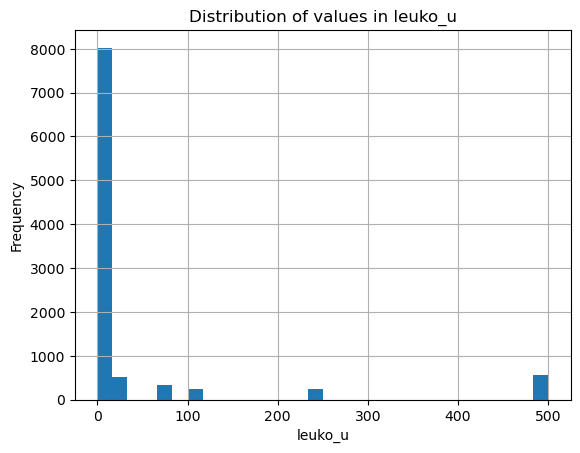


Analysis of column: proteinuria
count    9932.000000
mean        0.050745
std         0.219488
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: proteinuria, dtype: float64


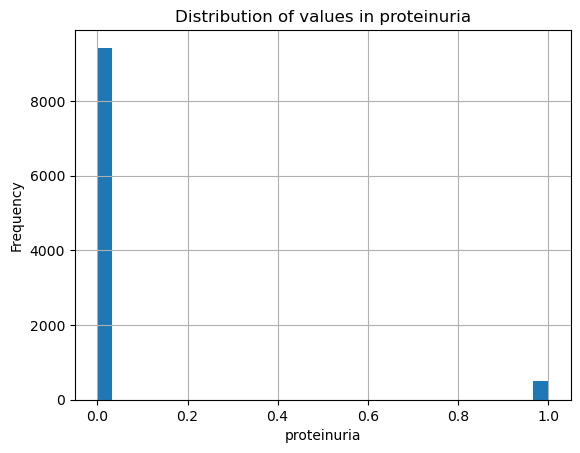

In [ ]:
# Analysis of the number of NaNs in columns
missing_columns = ['albumin', 'alb24h', 'ACR', 'gravity_u', 'nitrites_u', 'leuko_u', 'proteinuria']
print("Number of NaNs in each column:")
print(df[missing_columns].isna().sum())

# Analysis of data distribution in columns with NaNs
print("\nStatistics for columns with NaNs:")

for col in missing_columns:
    print(f"\nAnalysis of column: {col}")
    print(df[col].describe())

    # Plot a histogram for better visualization
    df[col].hist(bins=30)
    plt.title(f"Distribution of values in {col}")
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# ALBUMIN

In [ ]:
# Count the number of missing (NaN) values in the 'albumin' column
df['albumin'].isna().sum()

1463

In [ ]:
# Create an indicator variable for NaNs in the 'albumin' column
df['albumin_missing'] = df['albumin'].isna().astype(int)

In [ ]:
# Create a cross-tabulation to check the relationship between NaNs in 'albumin' and 'dead_5y'
cross_tab_albumin = pd.crosstab(df['albumin_missing'], df['dead_5y'], normalize='index')
print(cross_tab_albumin)

dead_5y                 0         1
albumin_missing                    
0                0.983964  0.016036
1                0.985646  0.014354


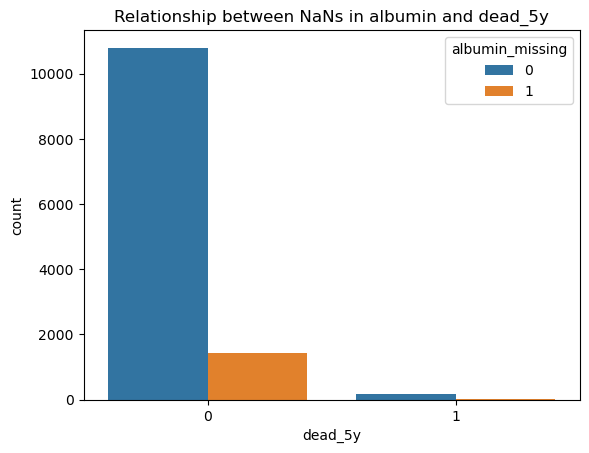

In [ ]:
# Visualize the relationship between NaNs in 'albumin' and 'dead_5y'
sns.countplot(x='dead_5y', hue='albumin_missing', data=df)
plt.title('Relationship between NaNs in albumin and dead_5y')
plt.show()

In [ ]:
# Calculate the correlation between 'albumin_missing' and 'dead_5y'
correlation = df[['albumin_missing', 'dead_5y']].corr()
print(f"Correlation between NaNs in albumin and dead_5y: {correlation.loc['albumin_missing', 'dead_5y']}")

Correlation between NaNs in albumin and dead_5y: -0.004341170358808052


In [ ]:
df = df.drop(columns=['albumin_missing'])

In [ ]:
# Apply iterative imputation to fill in missing values in 'albumin'
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer()
df['albumin'] = imputer.fit_transform(df[['albumin']])

In [ ]:
# Check if there are any missing values left in the 'albumin' column
df['albumin'].isna().sum()

0

# ALB24h

In [ ]:
# Count the number of missing (NaN) values in the 'albumin' column
df['alb24h'].isna().sum()

8918

In [ ]:
# Create an indicator variable for NaNs in the 'alb24h' column
df['alb24h_missing'] = df['alb24h'].isna().astype(int)

In [ ]:
# Create a cross-tabulation to examine the relationship between NaNs in 'alb24h' and the target variable 'dead_5y'
cross_tab = pd.crosstab(df['alb24h_missing'], df['dead_5y'], normalize='index')
print(cross_tab)

dead_5y               0        1
alb24h_missing                  
0               0.98267  0.01733
1               0.98475  0.01525


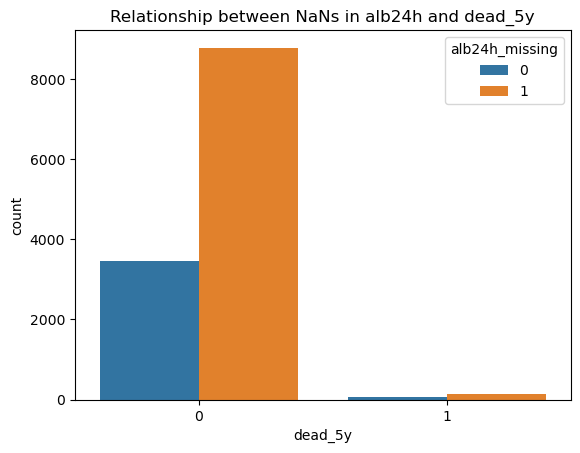

In [ ]:
# Visualize the relationship between NaNs in 'alb24h' and the target variable 'dead_5y'
sns.countplot(x='dead_5y', hue='alb24h_missing', data=df)
plt.title('Relationship between NaNs in alb24h and dead_5y')
plt.show()

In [ ]:
# Calculate the correlation between 'alb24h_missing' and 'dead_5y'
correlation = df[['alb24h_missing', 'dead_5y']].corr()
print(f"Correlation between NaNs in alb24h and dead_5y: {correlation.loc['alb24h_missing', 'dead_5y']}")

Correlation between NaNs in alb24h and dead_5y: -0.00750274545030546


In [ ]:
df = df.drop(columns=['alb24h_missing', 'alb24h'])
df.shape

(12438, 44)

# ACR

In [ ]:
# Count the number of missing (NaN) values in the 'ACR' column
df['ACR'].isna().sum()

1212

In [ ]:
# Create an indicator variable for NaNs in the 'ACR' column
df['ACR_missing'] = df['ACR'].isna().astype(int)

In [ ]:
# Create a cross-tabulation to check the relationship between NaNs in 'ACR' and 'dead_5y'
cross_tab_ACR = pd.crosstab(df['ACR_missing'], df['dead_5y'], normalize='index')
print(cross_tab_ACR)

dead_5y             0         1
ACR_missing                    
0            0.984678  0.015322
1            0.979373  0.020627


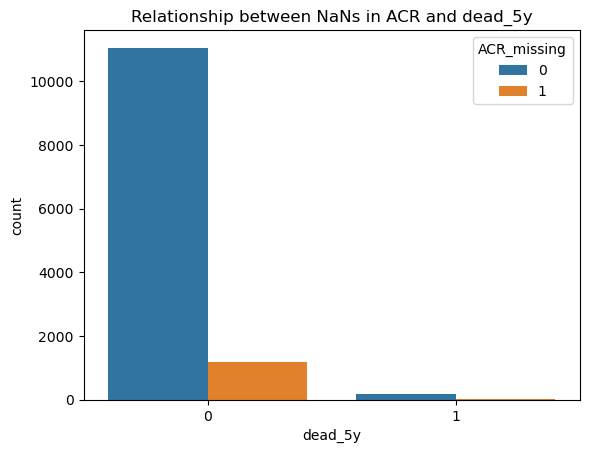

In [ ]:
# Visualize the relationship between NaNs in 'ACR' and 'dead_5y'
sns.countplot(x='dead_5y', hue='ACR_missing', data=df)
plt.title('Relationship between NaNs in ACR and dead_5y')
plt.show()

In [ ]:
# Calculate the correlation between 'ACR_missing' and 'dead_5y'
correlation = df[['ACR_missing', 'dead_5y']].corr()
print(f"Correlation between NaNs in ACR and dead_5y: {correlation.loc['ACR_missing', 'dead_5y']}")

Correlation between NaNs in ACR and dead_5y: 0.012602235360318065


In [ ]:
# Impute missing values in the 'ACR' column using Iterative Imputer
imputer = IterativeImputer()
df['ACR'] = imputer.fit_transform(df[['ACR']])

In [ ]:
df= df.drop(columns=['ACR_missing'])

In [ ]:
# Check if there are any missing values left in the 'albumin' column
df['ACR'].isna().sum()

0

# GRAVITY_U

In [ ]:
# Count the number of missing (NaN) values in the 'gravity_u' column
df['gravity_u'].isna().sum()

2530

In [ ]:
# Create an indicator variable for NaNs in the 'gravity_u' column
df['gravity_u_missing'] = df['gravity_u'].isna().astype(int)

In [ ]:
# Create a cross-tabulation to check the relationship between NaNs in 'gravity_u' and 'dead_5y'
cross_tab_gravity_u = pd.crosstab(df['gravity_u_missing'], df['dead_5y'], normalize='index')
print(cross_tab_gravity_u)

dead_5y                   0         1
gravity_u_missing                    
0                  0.984861  0.015139
1                  0.981423  0.018577


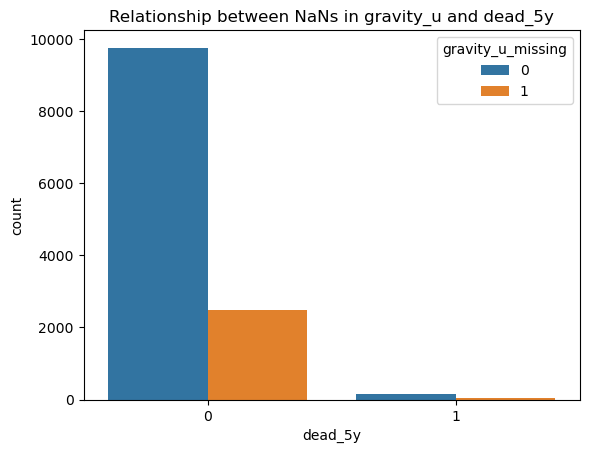

In [ ]:
# Visualize the relationship between NaNs in 'gravity_u' and 'dead_5y'
sns.countplot(x='dead_5y', hue='gravity_u_missing', data=df)
plt.title('Relationship between NaNs in gravity_u and dead_5y')
plt.show()

In [ ]:
# Calculate the correlation between 'gravity_u_missing' and 'dead_5y'
correlation = df[['gravity_u_missing', 'dead_5y']].corr()
print(f"Correlation between NaNs in gravity_u and dead_5y: {correlation.loc['gravity_u_missing', 'dead_5y']}")

Correlation between NaNs in gravity_u and dead_5y: 0.011083872213528667


In [ ]:
df= df.drop(columns=['gravity_u_missing'])

In [ ]:
# Impute missing values in the 'gravity_u' column using Iterative Imputer
imputer = IterativeImputer()
df['gravity_u'] = imputer.fit_transform(df[['gravity_u']])

In [ ]:
# Check if there are any missing values left in the 'gravity_u' column
df['gravity_u'].isna().sum()

0

# NITRITES_U

In [ ]:
# Count the number of missing (NaN) values in the 'nitrites_u' column
df['nitrites_u'].isna().sum()

2520

In [ ]:
# Create an indicator variable for NaNs in the 'nitrites_u' column
df['nitrites_u_missing'] = df['nitrites_u'].isna().astype(int)

In [ ]:
# Create a cross-tabulation to check the relationship between NaNs in 'nitrites_u' and 'dead_5y'
cross_tab_nitrites_u = pd.crosstab(df['nitrites_u_missing'], df['dead_5y'], normalize='index')
print(cross_tab_nitrites_u)

dead_5y                    0         1
nitrites_u_missing                    
0                   0.984876  0.015124
1                   0.981349  0.018651


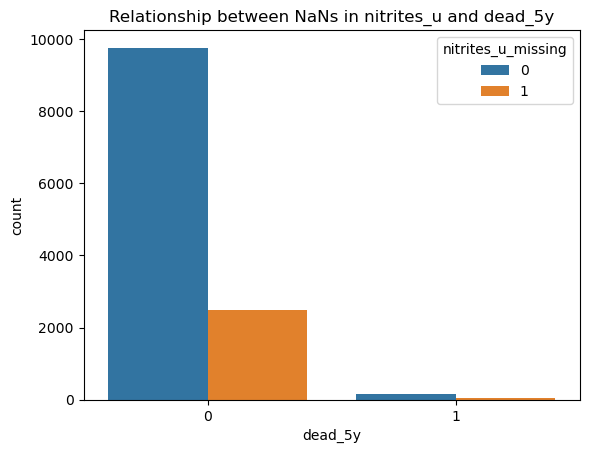

In [ ]:
# Visualize the relationship between NaNs in 'nitrites_u' and 'dead_5y'
sns.countplot(x='dead_5y', hue='nitrites_u_missing', data=df)
plt.title('Relationship between NaNs in nitrites_u and dead_5y')
plt.show()

In [ ]:
# Calculate the correlation between 'nitrites_u_missing' and 'dead_5y'
correlation = df[['nitrites_u_missing', 'dead_5y']].corr()
print(f"Correlation between NaNs in nitrites_u and dead_5y: {correlation.loc['nitrites_u_missing', 'dead_5y']}")

Correlation between NaNs in nitrites_u and dead_5y: 0.011353995681484914


In [ ]:
df= df.drop(columns=['nitrites_u_missing'])

In [ ]:
df['nitrites_u'].unique()

array([ 0., nan,  1.,  2.])

In [ ]:
# Calculate the percentage distribution of unique values in the 'nitrites_u' column
value_counts = df['nitrites_u'].value_counts(normalize=True) * 100
print(value_counts)

nitrites_u
0.0    96.460980
1.0     3.307118
2.0     0.231902
Name: proportion, dtype: float64


If, for example, 80% of the values are 0, filling with the mode would be a reasonable approach.

In [ ]:
# Fill the missing values with the mode (most frequent value)
df['nitrites_u'] = df['nitrites_u'].fillna(df['nitrites_u'].mode()[0])

In [ ]:
# Check if there are any missing values left in the 'nitrites_u' column
df['nitrites_u'].isna().sum()

0

# LEUKO_U

In [ ]:
# Count the number of missing (NaN) values in the 'nitrites_u' column
df['leuko_u'].isna().sum()

2507

In [ ]:
# Create an indicator variable for NaNs in the 'leuko_u' column
df['leuko_u_missing'] = df['leuko_u'].isna().astype(int)

In [ ]:
# Create a cross-tabulation to check the relationship between NaNs in 'leuko_u' and 'dead_5y'
cross_tab_leuko_u = pd.crosstab(df['leuko_u_missing'], df['dead_5y'], normalize='index')
print(cross_tab_leuko_u)

dead_5y                 0         1
leuko_u_missing                    
0                0.984896  0.015104
1                0.981252  0.018748


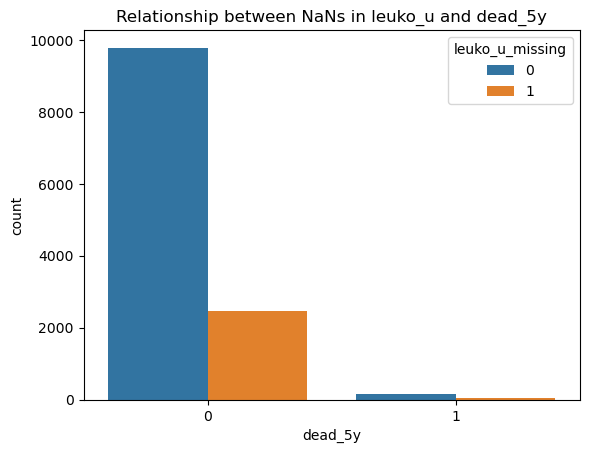

In [ ]:
# Visualize the relationship between NaNs in 'leuko_u' and 'dead_5y'
sns.countplot(x='dead_5y', hue='leuko_u_missing', data=df)
plt.title('Relationship between NaNs in leuko_u and dead_5y')
plt.show()

In [ ]:
# Calculate the correlation between 'leuko_u_missing' and 'dead_5y'
correlation = df[['leuko_u_missing', 'dead_5y']].corr()
print(f"Correlation between NaNs in leuko_u and dead_5y: {correlation.loc['leuko_u_missing', 'dead_5y']}")

Correlation between NaNs in leuko_u and dead_5y: 0.011706459947245932


In [ ]:
df = df.drop(columns=['leuko_u_missing'])

In [ ]:
df['leuko_u'].unique()

array([  0.,   1.,  nan,  75., 100.,  25., 250., 500.,   4.,   2.,   3.])

In [ ]:
# Calculate the percentage distribution of unique values in the 'leuko_u' column
value_counts = df['leuko_u'].value_counts(normalize=True) * 100
print(value_counts)

leuko_u
0.0      79.740207
500.0     5.719464
25.0      5.276407
75.0      3.433692
250.0     2.396536
100.0     2.346189
1.0       0.432988
2.0       0.352432
4.0       0.191320
3.0       0.110764
Name: proportion, dtype: float64


In [ ]:
# Fill the missing values with the mode (most frequent value)
df['leuko_u'] = df['leuko_u'].fillna(df['leuko_u'].mode()[0])

In [ ]:
# Check if there are any missing values left in the 'leuko_u' column
df['leuko_u'].isna().sum()

0

# PROTEINURIA

In [ ]:
# Count the number of missing (NaN) values in the 'proteinuria' column
df['proteinuria'].isna().sum()

2506

In [ ]:
# Create an indicator variable for NaNs in the 'proteinuria' column
df['proteinuria_missing'] = df['proteinuria'].isna().astype(int)

In [ ]:
# Create a cross-tabulation to check the relationship between NaNs in 'proteinuria' and 'dead_5y'
cross_tab_proteinuria = pd.crosstab(df['proteinuria_missing'], df['dead_5y'], normalize='index')
print(cross_tab_proteinuria)

dead_5y                     0         1
proteinuria_missing                    
0                    0.984897  0.015103
1                    0.981245  0.018755


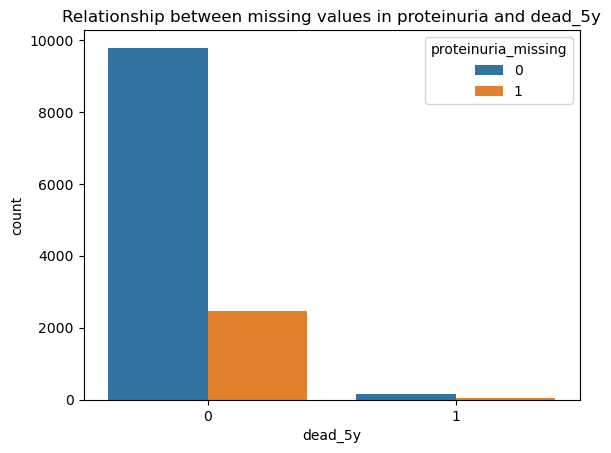

In [ ]:
# Visualize the relationship between NaNs in 'proteinuria' and 'dead_5y'
sns.countplot(x='dead_5y', hue='proteinuria_missing', data=df)
plt.title('Relationship between missing values in proteinuria and dead_5y')
plt.show()

In [ ]:
# Calculate the correlation between 'proteinuria_missing' and 'dead_5y'
correlation = df[['proteinuria_missing', 'dead_5y']].corr()
print(f"Correlation between NaNs in proteinuria and dead_5y: {correlation.loc['proteinuria_missing', 'dead_5y']}")

Correlation between NaNs in proteinuria and dead_5y: 0.011733634146946984


In [ ]:
df= df.drop(columns=['proteinuria_missing'])

In [ ]:
df['proteinuria'].unique()

array([ 0., nan,  1.])

In [ ]:
# Calculate the percentage distribution of unique values in the 'proteinuria' column
value_counts = df['proteinuria'].value_counts(normalize=True) * 100
print(value_counts)

proteinuria
0.0    94.925493
1.0     5.074507
Name: proportion, dtype: float64


In [ ]:
# Fill the missing values with the mode (most frequent value)
df['proteinuria'] = df['proteinuria'].fillna(df['proteinuria'].mode()[0])

In [ ]:
# Check if there are any missing values left in the 'proteinuria' column
df['proteinuria'].isna().sum()

0

In [ ]:
df.shape

(12438, 44)

In [ ]:
print(df.isna().sum())

age                    0
sex                    0
marital_status         0
ses                    0
residence_cd           0
residence              0
weigh                  0
heigh                  0
BMI                    0
bp_sys                 0
bp_dias                0
bp_cat                 0
smoking                0
smoking_status         0
HbA1c                  0
glucose                0
creatinin              0
albumin                0
ACR                    0
cholesterol_total      0
LDL                    0
HDL                    0
triglycerides          0
TSH                    0
gravity_u              0
nitrites_u             0
leuko_u                0
proteinuria            0
WBC                    0
RBC                    0
platelets              0
MCV                    0
MPV                    0
Charlson               0
framingham_cvd         0
antidiabetics          0
ERD                    0
CVD                    0
HTN                    0
cancer                 0


# Categorical Encoding

# smoking and smoking_status

In [ ]:
unique_values = df['smoking'].unique()
unique_values

array([1, 3, 2], dtype=int64)

In [ ]:
unique_values = df['smoking_status'].unique()
unique_values

array(['non_smoker', 'current_smoker', 'past_smoker'], dtype=object)

In [ ]:
df = df.drop(columns=['smoking_status'])
df.shape

(12438, 43)

# bp_sys, bp_dias, bp_cat

In [ ]:
unique_values = df['bp_sys'].unique()
unique_values

array([116, 113, 133, 100, 110, 115, 123, 120, 137, 130, 108, 106, 129,
       125, 117, 167, 118, 140, 107, 112, 128, 136, 127, 111, 126, 124,
       155, 135, 150, 141, 114, 109, 102, 138, 121, 148, 160, 145, 134,
       103, 149, 132, 105, 104,  99, 144, 122, 170, 119, 142, 143, 199,
       154, 131, 139, 156,  97, 181, 180, 189, 185,  94, 157,  90,  96,
       101, 151, 161, 171, 166, 169, 200, 146, 152, 153,  92, 159,  98,
        79,  95, 177, 173, 147,  85, 162, 158, 165, 190, 172, 164,  91,
        93, 163,  80,  81, 178, 175, 187,  86,  87, 174, 176, 195, 194,
        82,  75], dtype=int64)

In [ ]:
unique_values = df['bp_dias'].unique()
unique_values

array([ 66,  74,  87,  63,  70,  80,  84,  60,  76,  69,  65,  89,  86,
        77,  85,  90,  79,  62,  78,  67,  81,  61,  75,  82, 107,  96,
        71,  91,  64,  73,  72,  98,  95, 100,  68,  83, 101,  88,  94,
       111,  92, 117, 106,  55,  48,  93, 105,  58,  57,  99,  56,  50,
        49, 110,  59,  40, 120,  97, 103,  54,  53, 104, 102,  52, 115,
        51,  41,  42, 109,  45, 113, 126, 135, 108,  47], dtype=int64)

In [ ]:
unique_values = df['bp_cat'].unique()
unique_values

array(['Normal', 'Pre-HTN', 'HTN-G2', 'HTN-G1', 'HTN-G3'], dtype=object)

In [ ]:
# Correlation of numerical features with the target variable
corr_sys = df['bp_sys'].corr(df['dead_5y'])
corr_dias = df['bp_dias'].corr(df['dead_5y'])
print(f'Correlation of bp_sys: {corr_sys}')
print(f'Correlation of bp_dias: {corr_dias}')

Correlation of bp_sys: 0.055082818788480585
Correlation of bp_dias: 0.021302501259211938


In [ ]:
# Analyze blood pressure categories based on the target variable
cross_tab = pd.crosstab(df['bp_cat'], df['dead_5y'], normalize='index')
print(cross_tab)

dead_5y         0         1
bp_cat                     
HTN-G1   0.978711  0.021289
HTN-G2   0.942779  0.057221
HTN-G3   0.920000  0.080000
Normal   0.986926  0.013074
Pre-HTN  0.987184  0.012816


In [ ]:
df = df.drop(columns=['bp_sys', 'bp_dias'])
df.shape

(12438, 41)

'Normal' → 0<br>
'Pre-HTN' → 1<br>
'HTN-G1' → 2<br>
'HTN-G2' → 3<br>
'HTN-G3'  → 4

In [ ]:
# Define a mapping for blood pressure categories
mapping = {
    'Normal': 0,
    'Pre-HTN': 1,
    'HTN-G1': 2,
    'HTN-G2': 3,
    'HTN-G3': 4
}

# Apply the mapping directly to the 'bp_cat' column to replace the values with the corresponding numerical categories
df['bp_cat'] = df['bp_cat'].map(mapping)

In [ ]:
unique_values = df['bp_cat'].unique()
unique_values

array([0, 1, 3, 2, 4], dtype=int64)

# residence_cd and residence

In [ ]:
unique_values = df['residence_cd'].unique()
unique_values

array([1, 2], dtype=int64)

In [ ]:
unique_values = df['residence'].unique()
unique_values

array(['urban', 'rural'], dtype=object)

In [ ]:
df = df.drop(columns=['residence'])
df.shape

(12438, 40)

# marital_status

In [ ]:
unique_values = df['marital_status'].unique()
unique_values

array(['U', 'M'], dtype=object)

In [ ]:
# Create a dictionary for value replacement: M -> 1 (married), U -> 0 (unmarried)
mapping = {'M': 1, 'U': 0}

# Прямо в столбце 'marital_status' заменим значения
df['marital_status'] = df['marital_status'].map(mapping)

In [ ]:
unique_values = df['marital_status'].unique()
unique_values

array([0, 1], dtype=int64)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12438 entries, 0 to 12437
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  12438 non-null  int64  
 1   sex                  12438 non-null  int64  
 2   marital_status       12438 non-null  int64  
 3   ses                  12438 non-null  int64  
 4   residence_cd         12438 non-null  int64  
 5   weigh                12438 non-null  float64
 6   heigh                12438 non-null  float64
 7   BMI                  12438 non-null  float64
 8   bp_cat               12438 non-null  int64  
 9   smoking              12438 non-null  int64  
 10  HbA1c                12438 non-null  float64
 11  glucose              12438 non-null  int64  
 12  creatinin            12438 non-null  float64
 13  albumin              12438 non-null  float64
 14  ACR                  12438 non-null  float64
 15  cholesterol_total    12438 non-null 

# Data Cleaning

In [ ]:
check_duplicates=df.copy()
check_duplicates.drop_duplicates()
check_duplicates.shape

(12438, 40)

In [ ]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"'{column}':")
    print(unique_values)
    print("\n")

'age':
[49 46 45 41 47 42 44 33 43 48 39 40 35 31 36 38 37 34 32 30]


'sex':
[2 1]


'marital_status':
[0 1]


'ses':
[1 2 3]


'residence_cd':
[1 2]


'weigh':
[ 84.    67.    62.4   73.9   53.   107.    89.    85.    87.    72.
 112.    90.    60.    98.5   64.5   55.   100.    78.   105.    83.
 122.   115.   120.    99.2  118.   100.5   92.    69.   103.7  102.
  75.    88.    66.5   58.   106.   119.5   97.    70.    48.   116.
  78.8   78.2  101.1   98.    93.    88.4  107.6   86.7  108.   132.
  65.   110.    85.4   79.   111.    63.    77.    73.   109.    80.
 141.5  125.    62.   152.    60.85 104.    81.   103.    51.    82.
  79.9   61.    91.    96.   127.   106.5   74.    94.    80.1  125.6
  62.5  106.7  123.    49.    84.6   95.   128.    81.6   66.    77.9
  76.   163.    77.5  130.   114.    88.3   64.    69.6  131.8  124.5
  59.    86.   101.    71.5   71.    75.9   82.5   75.6   77.7  117.
  68.    89.1  124.   156.    86.3   99.    85.5   94.5  123.5   74.6
  94.9

In [ ]:
# Drop the 'cancer' column because it contains only zeros
df = df.drop(columns=['cancer'])
df.shape

(12438, 39)

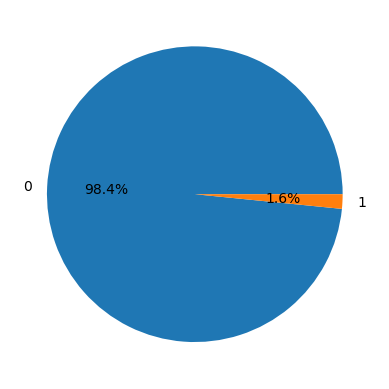

In [ ]:
# Visualize the distribution of the target variable 'dead_5y' using a pie chart
x = df['dead_5y'].value_counts()
plt.pie(x.values,
		labels = x.index,
		autopct='%1.1f%%')
plt.show()

In [ ]:
# This function removes highly correlated features (correlation > 0.7) from the DataFrame, except for the target column ('dead_5y').
columns = list(df.columns)
removed_columns = []

# Ensure 'dead_5y' is not removed by excluding it from the columns list
columns.remove('dead_5y')

for col in columns:
    filtered_columns = [col]
    for col1 in df.columns:
        if col == col1 or col1 == 'dead_5y':  # Ensure 'dead_5y' is skipped
            continue

        val = df[col].corr(df[col1])

        if val > 0.7:
            # Print the removed column and the correlation value
            print(f"Removing column '{col1}' due to high correlation ({val:.2f}) with column '{col}'")
            removed_columns.append((col1, val))
            columns.remove(col1)
            continue
        else:
            filtered_columns.append(col1)

    # After each iteration, filter out the columns which are not highly correlated features.
    df = df[filtered_columns + ['dead_5y']]  # Ensure 'dead_5y' is always included

print(f"Final shape of the DataFrame: {df.shape}")
print(f"Removed columns: {removed_columns}")

Removing column 'BMI' due to high correlation (0.82) with column 'weigh'
Removing column 'glucose' due to high correlation (0.77) with column 'HbA1c'
Removing column 'LDL' due to high correlation (0.80) with column 'cholesterol_total'
Final shape of the DataFrame: (12438, 36)
Removed columns: [('BMI', 0.8169976385015647), ('glucose', 0.7680960538059775), ('LDL', 0.7956319274826276)]


In [ ]:
# Split the DataFrame into features and target
features = df.drop('dead_5y', axis=1)
target = df['dead_5y']

In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Select the best features using ANOVA F-value
from sklearn.feature_selection import SelectKBest, f_classif

selector_f = SelectKBest(f_classif, k=30)
X_new_f = selector_f.fit_transform(X_scaled, target)
selected_features_f = selector_f.get_support(indices=True)
selected_feature_names_f = features.columns[selected_features_f]
print("Selected features names using ANOVA F-value:", selected_feature_names_f)

Selected features names using ANOVA F-value: Index(['immigrant', 'HTN', 'CVD', 'ERD', 'antidiabetics', 'framingham_cvd',
       'Charlson', 'MPV', 'MCV', 'RBC', 'WBC', 'proteinuria', 'leuko_u',
       'nitrites_u', 'TSH', 'triglycerides', 'HDL', 'cholesterol_total', 'ACR',
       'albumin', 'creatinin', 'HbA1c', 'smoking', 'bp_cat', 'heigh', 'weigh',
       'ses', 'marital_status', 'sex', 'age'],
      dtype='object')


# Model Training

In [ ]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X_new_f, target, test_size=0.2, random_state=10)
X_train.shape, X_test.shape

((9950, 30), (2488, 30))

In [ ]:
# Apply oversampling only to the training data to balance the minority class
ros = RandomOverSampler(sampling_strategy='minority', random_state=0)
X_resampled, Y_resampled = ros.fit_resample(X_train, Y_train)

print(X_train.shape, X_test.shape)

print(X_resampled.shape, Y_resampled.shape)

(9950, 30) (2488, 30)
(19588, 30) (19588,)


In [ ]:
# Check the class distribution after balancing
y_resampled_distribution = pd.Series(Y_resampled).value_counts(normalize=True) * 100
print(y_resampled_distribution)

dead_5y
0    50.0
1    50.0
Name: proportion, dtype: float64


In [ ]:
# Import the models and necessary tools for evaluation
from sklearn.linear_model import LogisticRegression, Perceptron
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score

# List of models to test
models = [
    LogisticRegression(),
    XGBClassifier(),
    SVC(kernel='rbf', probability=True),
    RandomForestClassifier(),
    KNeighborsClassifier(),
    GradientBoostingClassifier(),
    DecisionTreeClassifier(),
    Perceptron(),
    GaussianNB()
]

# Loop through each model to train and evaluate
for i in range(len(models)):
    models[i].fit(X_resampled, Y_resampled)

    print(f'{models[i].__class__.__name__} : ')

    # Make predictions for the training and test sets
    if hasattr(models[i], 'predict_proba'):
        train_preds = models[i].predict_proba(X_resampled)[:, 1]
        test_preds = models[i].predict_proba(X_test)[:, 1]
    elif hasattr(models[i], 'decision_function'):
        train_preds = models[i].decision_function(X_resampled)
        test_preds = models[i].decision_function(X_test)
    else:
        train_preds = models[i].predict(X_resampled)
        test_preds = models[i].predict(X_test)

    # Calculate and print AUC scores for training and validation sets
    print('Training AUC: ', roc_auc_score(Y_resampled, train_preds)) # AUC on training data
    print('Validation AUC: ', roc_auc_score(Y_test, test_preds)) # AUC on validation data
    print()

LogisticRegression : 
Training AUC:  0.8216576463925499
Validation AUC:  0.8191314401905767

XGBClassifier : 
Training AUC:  1.0
Validation AUC:  0.7410368096325017

SVC : 
Training AUC:  0.9986677777866275
Validation AUC:  0.7416049518075891

RandomForestClassifier : 
Training AUC:  1.0
Validation AUC:  0.7872108206165838

KNeighborsClassifier : 
Training AUC:  1.0
Validation AUC:  0.5451722866227436

GradientBoostingClassifier : 
Training AUC:  0.9795910625122156
Validation AUC:  0.8087055329073928

DecisionTreeClassifier : 
Training AUC:  1.0
Validation AUC:  0.5540283273695018

Perceptron : 
Training AUC:  0.7336386348653615
Validation AUC:  0.7551307225373031

GaussianNB : 
Training AUC:  0.7860912227041441
Validation AUC:  0.8031536874420644



# SVC

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Splitting the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, random_state=10, stratify=Y_resampled)

# Creating the SVC model
svc = SVC(probability=True, random_state=0)

# Training the model
svc.fit(X_train, Y_train)

# Predictions on the training data
train_preds = svc.predict(X_train)
print('Training AUC: ', roc_auc_score(Y_train, svc.predict_proba(X_train)[:, 1]))
print('Classification Report on the training data:')
print(classification_report(Y_train, train_preds))

# Predictions on the validation data
test_preds = svc.predict(X_test)
print('Validation AUC: ', roc_auc_score(Y_test, svc.predict_proba(X_test)[:, 1]))
print('Classification Report on the validation data:')
print(classification_report(Y_test, test_preds))

# Confusion Matrix on the validation data
print('Confusion Matrix on the validation data:')
print(confusion_matrix(Y_test, test_preds))

Training AUC:  0.9980456682966203
Classification Report on the training data:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      7835
           1       0.98      0.99      0.99      7835

    accuracy                           0.99     15670
   macro avg       0.99      0.99      0.99     15670
weighted avg       0.99      0.99      0.99     15670

Validation AUC:  0.9977358722624419
Classification Report on the validation data:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1959
           1       0.97      0.99      0.98      1959

    accuracy                           0.98      3918
   macro avg       0.98      0.98      0.98      3918
weighted avg       0.98      0.98      0.98      3918

Confusion Matrix on the validation data:
[[1908   51]
 [  10 1949]]


# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Splitting the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, random_state=10)

# Creating the Gradient Boosting model
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0)

# Training the model
gbc.fit(X_train, Y_train)

# Predictions on the training data
train_preds = gbc.predict(X_train)
print('Training AUC: ', roc_auc_score(Y_train, gbc.predict_proba(X_train)[:, 1]))
print('Classification Report on the training data:')
print(classification_report(Y_train, train_preds))

# Predictions on the validation data
test_preds = gbc.predict(X_test)
print('Validation AUC: ', roc_auc_score(Y_test, gbc.predict_proba(X_test)[:, 1]))
print('Classification Report on the validation data:')
print(classification_report(Y_test, test_preds))

# Confusion Matrix on the validation data
print('Confusion Matrix on the validation data:')
print(confusion_matrix(Y_test, test_preds))

Training AUC:  0.9796589594316398
Classification Report on the training data:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      7845
           1       0.91      0.94      0.93      7825

    accuracy                           0.93     15670
   macro avg       0.93      0.93      0.93     15670
weighted avg       0.93      0.93      0.93     15670

Validation AUC:  0.9778355166965856
Classification Report on the validation data:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      1949
           1       0.91      0.95      0.93      1969

    accuracy                           0.93      3918
   macro avg       0.93      0.93      0.93      3918
weighted avg       0.93      0.93      0.93      3918

Confusion Matrix on the validation data:
[[1773  176]
 [ 107 1862]]


# LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Splitting the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, random_state=10)

# Initializing the Logistic Regression model with class balancing
logreg = LogisticRegression(class_weight='balanced', max_iter=200, solver='liblinear')

# Training the model
logreg.fit(X_train, Y_train)

# Predictions on the training data
train_preds = logreg.predict(X_train)
train_auc = roc_auc_score(Y_train, logreg.predict_proba(X_train)[:, 1])
print('Training AUC: ', train_auc)
print('Classification Report on the training data:')
print(classification_report(Y_train, train_preds))

# Predictions on the validation data
test_preds = logreg.predict(X_test)
test_auc = roc_auc_score(Y_test, logreg.predict_proba(X_test)[:, 1])
print('Validation AUC: ', test_auc)
print('Classification Report on the validation data:')
print(classification_report(Y_test, test_preds))

# Confusion Matrix on the validation data
conf_matrix = confusion_matrix(Y_test, test_preds)
print('Confusion Matrix on the validation data:')
print(conf_matrix)

Training AUC:  0.8174092042916165
Classification Report on the training data:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75      7845
           1       0.75      0.77      0.76      7825

    accuracy                           0.75     15670
   macro avg       0.75      0.75      0.75     15670
weighted avg       0.75      0.75      0.75     15670

Validation AUC:  0.835548226864788
Classification Report on the validation data:
              precision    recall  f1-score   support

           0       0.78      0.77      0.77      1949
           1       0.77      0.78      0.78      1969

    accuracy                           0.77      3918
   macro avg       0.77      0.77      0.77      3918
weighted avg       0.77      0.77      0.77      3918

Confusion Matrix on the validation data:
[[1494  455]
 [ 431 1538]]
